# Fully Connected Neural Network for MNIST Digit Classification

## MNIST Database

- The MNIST database is a standard benchmark dataset for training and testing neural networks.
- It consists of:
   - 60,000 training images
   - 10,000 test images
- Each image is:
   - 28 × 28 pixels
   - Grayscale (pixel values normalized between 0 and 1)
- Each image is labeled with the correct digit (0–9)
- Widely used for:
   - Testing classification algorithms
   - Learning basic concepts in machine learning and deep learning

## Data Splitting

- The original MNIST database consists of:
   - 60,000 training images
   - 10,000 test images
- In this setup, the 60,000 training images are further divided into:
   - 50,000 images → Training set
   - 10,000 images → Validation set
- The test set (10,000 images) remains unchanged and is used only for final evaluation.

**Purpose of Each Set:**
- Training set (50,000):
   - Used to learn weights and biases of the neural network
- Validation set (10,000):
   - Used to tune hyperparameters such as:
      - learning rate
      - network architecture
   - Not used for training the model directly
- Test set (10,000):
   - Used to evaluate final performance of the trained model

## Feed Forward Fully Connected Network Architecture

- The input layer has 784 neurons corresponding to a 28 × 28 grayscale image, where each neuron encodes a pixel value between 0 (white) and 1 (black).
- The hidden layer contains n neurons (e.g., n = 30), and its size can be varied. These neurons learn to detect useful features or patterns in the image.
- The output layer has 10 neurons, each representing a digit from 0 to 9. The neuron with the highest activation determines the predicted digit.
- Although 4 output neurons could encode 10 digits using binary representation, this approach performs worse in practice.
- Using 10 output neurons is more effective because each neuron directly corresponds to a digit, making it easier for the network to learn from features extracted by the hidden layer.
- The explanation of hidden neurons detecting component shapes is a heuristic, not a strict rule, but it helps in understanding and designing neural networks.

## Import Modules

In [1]:
# Import built-in modules from Python's standard library
import os
import gzip
import urllib.request

# Import Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
# sklearn.datasets : module with ready-to-use datasets
# fetch_openml : downloads datasets from OpenML repository

## Initialize Random Number Generator Object

In [2]:
rng = np.random.default_rng(42)

## Loading MNIST Image Data from OpenML

In [3]:
_ = """
# Download MNIST
# MNIST images are 28 × 28 = 784 pixels
# Each image is flattened → vector of size 784
# Returns a dictionary-like object (Bunch)
mnist = fetch_openml('mnist_784', version=1)

# Extract Features (Data)
X = mnist.data

# Extract labels (Target)
y = mnist.target.astype(int)

# Visualize 10 Random Images
n_images = 10
indices = np.random.randint(0, len(X), n_images)
plt.figure(figsize=(10, 4))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X.iloc[idx].values.reshape(28, 28), cmap='gray')
    plt.title(f"{y[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# First split: train+val and test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=10000,
    stratify=y,
    random_state=42
)

# Second split: train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=10000,
    stratify=y_train_full,
    random_state=42
)

# Normalize (Min-Max Scaling)
X_train = X_train / 255.0
X_val   = X_val   / 255.0
X_test  = X_test  / 255.0
"""

## Loading MNIST directly

### Download Files

In [4]:
base_url = "https://storage.googleapis.com/cvdf-datasets/mnist/"

files = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz"
]

os.makedirs("mnist_data", exist_ok=True)

for file in files:
    url = base_url + file
    path = os.path.join("mnist_data", file)
    
    if not os.path.exists(path):
        print(f"Downloading {file}...")
        urllib.request.urlretrieve(url, path)

print("Download completed")

Download completed


### Load images

In [5]:
def load_images(filename):
    with gzip.open(filename, 'rb') as f:
        data = np.frombuffer(f.read(), np.uint8, offset=16)
        return data.reshape(-1, 28, 28)

def load_labels(filename):
    with gzip.open(filename, 'rb') as f:
        return np.frombuffer(f.read(), np.uint8, offset=8)

### Read dataset

In [6]:
X_train = load_images("mnist_data/train-images-idx3-ubyte.gz")
y_train = load_labels("mnist_data/train-labels-idx1-ubyte.gz")

X_test = load_images("mnist_data/t10k-images-idx3-ubyte.gz")
y_test = load_labels("mnist_data/t10k-labels-idx1-ubyte.gz")

### Visualize Images

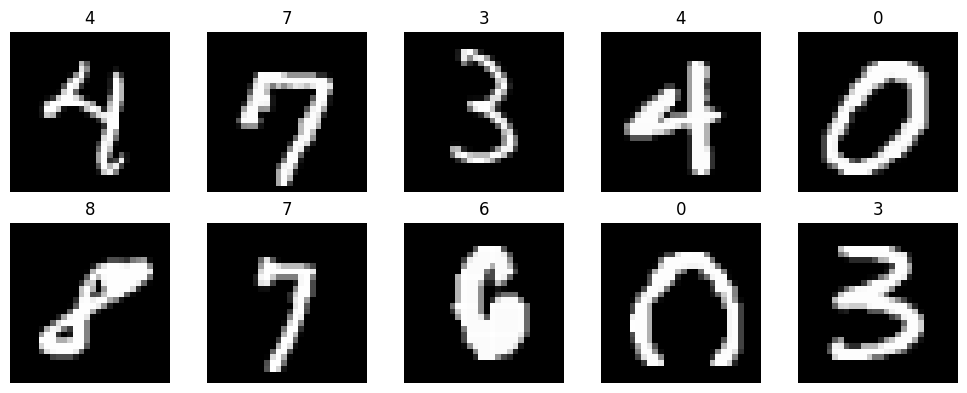

In [7]:
# Visualize 10 Random Images
n_images = 10
indices = np.random.randint(0, len(X_train), n_images)
plt.figure(figsize=(10, 4))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"{y_train[idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

### Create validation set

In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=10000,
    stratify=y_train,
    random_state=42
)

### Normalize : Min-Max Scaling

In [9]:
X_train = X_train / 255.0
X_test  = X_test / 255.0
X_val   = X_val / 255.0

### Flatten the Images

In [10]:
# Flatten images: (N, 28, 28) → (N, 784)
X_train = X_train.reshape(X_train.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)

# Verify Shapes
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (50000, 784)
X_val shape: (10000, 784)
X_test shape: (10000, 784)
y_train shape: (50000,)
y_val shape: (10000,)
y_test shape: (10000,)


### Convert to Float32 (Optional but Recommended)

In [11]:
# Saves memory
# Faster training on most frameworks
X_train = X_train.astype(np.float32)
X_val   = X_val.astype(np.float32)
X_test  = X_test.astype(np.float32)

### One hot encoding of labels

In [12]:
def vectorized_label(label):
    label_vector = np.zeros((10, 1))
    label_vector[label] = 1.0
    return label_vector

In [13]:
y_train_oh = [vectorized_label(label) for label in y_train]
y_val_oh = [vectorized_label(label) for label in y_val]
y_test_oh = [vectorized_label(label) for label in y_test]

print("y_train_oh shape:", np.array(y_train_oh).shape)
print("y_val_oh shape:", np.array(y_val_oh).shape)
print("y_test_oh shape:", np.array(y_test_oh).shape)

y_train_oh shape: (50000, 10, 1)
y_val_oh shape: (10000, 10, 1)
y_test_oh shape: (10000, 10, 1)


In [14]:
training_data = list(zip(X_train, y_train_oh))
validation_data = list(zip(X_val, y_val_oh))
testing_data = list(zip(X_test, y_test_oh))

### Layers

In [15]:
sizes = [784, 30, 10]

### Initialize biases

In [16]:
# Biases don’t need randomness (usually)
biases = [np.zeros((size, 1)) for size in sizes[1:]]

### Xavier (Glorot) Initialization for Weights

In [17]:
# Best for Sigmoid, Tanh 
weights = [
    rng.normal(0, np.sqrt(2 / (curr + next)), size=(next, curr))
    for curr, next in zip(sizes[:-1], sizes[1:])
]

## SGD

In [18]:
n_train = len(X_train)
epochs = 30
mini_batch_size = 10
eta = 3.0

In [ ]:
#### Miscellaneous functions
def sigmoid(z):
    """The sigmoid function."""
    return 1.0/(1.0+np.exp(-z))

def sigmoid_prime(z):
    """Derivative of the sigmoid function."""
    return sigmoid(z)*(1-sigmoid(z))

In [ ]:
def backprop(x, y):
    """Return a tuple ``(nabla_b, nabla_w)`` representing the
    gradient for the cost function C_x.  ``nabla_b`` and
    ``nabla_w`` are layer-by-layer lists of numpy arrays, similar
    to ``self.biases`` and ``self.weights``."""
    nabla_b = [np.zeros(b.shape) for b in biases]
    nabla_w = [np.zeros(w.shape) for w in weights]
    # feedforward
    activation = x
    activations = [x] # list to store all the activations, layer by layer
    zs = [] # list to store all the z vectors, layer by layer
    for b, w in zip(self.biases, self.weights):
        z = np.dot(w, activation)+b
        zs.append(z)
        activation = sigmoid(z)
        activations.append(activation)
    # backward pass
    delta = cost_derivative(activations[-1], y) * \
        sigmoid_prime(zs[-1])
    nabla_b[-1] = delta
    nabla_w[-1] = np.dot(delta, activations[-2].transpose())
    # Note that the variable l in the loop below is used a little
    # differently to the notation in Chapter 2 of the book.  Here,
    # l = 1 means the last layer of neurons, l = 2 is the
    # second-last layer, and so on.  It's a renumbering of the
    # scheme in the book, used here to take advantage of the fact
    # that Python can use negative indices in lists.
    for l in xrange(2, self.num_layers):
        z = zs[-l]
        sp = sigmoid_prime(z)
        delta = np.dot(self.weights[-l+1].transpose(), delta) * sp
        nabla_b[-l] = delta
        nabla_w[-l] = np.dot(delta, activations[-l-1].transpose())
    return (nabla_b, nabla_w)

In [19]:
def update_mini_batch(mini_batch, eta):
    """
    Update the network's weights and biases by applying
    gradient descent using backpropagation to a single mini batch.
    The mini_batch is a list of tuples (x, y), and eta is 
    the learning rate.
    """
    nabla_b = [np.zeros(b.shape) for b in biases]
    nabla_w = [np.zeros(w.shape) for w in weights]
    for x, y in mini_batch:
        delta_nabla_b, delta_nabla_w = self.backprop(x, y)
        nabla_b = [nb+dnb for nb, dnb in zip(nabla_b, delta_nabla_b)]
        nabla_w = [nw+dnw for nw, dnw in zip(nabla_w, delta_nabla_w)]
    weights = [w-(eta/len(mini_batch))*nw
                    for w, nw in zip(self.weights, nabla_w)]
    biases = [b-(eta/len(mini_batch))*nb
                   for b, nb in zip(self.biases, nabla_b)]

In [20]:
# Mini-batches for SDG
for epoch in range(epochs):
    rng.shuffle(training_data)
    mini_batches = [ training_data[k:k+mini_batch_size] for k in range(0, n_train, mini_batch_size)]

for mini_batch in mini_batches:
    update_mini_batch(mini_batch, eta)